In [41]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pickle

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner

## Important functions for binning

In [2]:
def bindown_single(w1, d1, w2, d2, output, noise, transits):
    wf = (w1 + w2) / 2
    df = (w2 + d2/2) - (w1 - d1/2)

    photogrid = np.array([[wf], [df]])

    fb2 = FluxBinner(photogrid[0], photogrid[1])

    # returns wavelength, value, and error
    wl, val, err, *_ = fb2.bindown(
        output[0], output[1],
        error=noise/np.sqrt(transits)
    )

    return w1, w2, wl[0], val[0], err[0], df

def make_next_level_points(results):
    """
    results: list of (w1, w2, wl, val, err, df)
             length must be even
    returns: list of (w1, d1, w2, d2)
    """

    assert len(results) % 2 == 0

    new_points = []

    for i in range(0, len(results), 2):
        left_bin  = results[i]
        right_bin = results[i + 1]

        # left edge of combined bin
        w1 = left_bin[2] - left_bin[5] / 2
        # right edge of combined bin
        w2 = right_bin[2] + right_bin[5] / 2

        width = w2 - w1

        new_points.append((w1, width, w2, width))

    return new_points

def bindown_multiple(output, noise, wlgrid, fpfs, transits, name, *new_points):
    all_results = []

    for (w1, d1, w2, d2) in new_points:
        out_i = bindown_single(w1, d1, w2, d2, output, noise, transits)
        all_results.append(out_i)

    return all_results

In [3]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii

star_temperature = [5261,4570,3381,4850,4440,5342,4884,4914] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr

In [4]:
#binning points examples

new_point1 = (0.95,0.3,1.156,0.112)
new_point2 = (1.549, 0.151, 1.708, 0.166)

new_point3 = (2.356, 0.0468, 2.403,0.0478)
new_point4 = (2.451, 0.0487, 2.500,0.0497)

new_point5 = (2.762,0.0549, 2.818, 0.056)
new_point6 = (2.875,0.057, 2.932, 0.058)

new_point7 = (3.439, 0.068, 3.507, 0.0690)
new_point8 = (3.578, 0.071, 3.65, 0.072)

new_point9 = (3.723, 0.074, 4.032, 0.264)
new_point10 = (4.30, 0.282, 4.597, 0.301)

new_point11 = (5.597,0.367, 5.976, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

## Go through all simulations and save TP profiles for TauREx

In [ ]:
for i, planet in enumerate(planet_names):
    #find file ending in atm.nc in each simulation folder within the planet directory
    for folder in os.listdir(f"PLANETS/{planet}/"):
        simulation_folder = os.path.join(f"PLANETS/{planet}/", folder)

        #check that it is a directory
        if not os.path.isdir(simulation_folder):
            continue

        print(f"Processing {simulation_folder}...")
        atm_file = None
        for file in os.listdir(simulation_folder):
            if file.endswith("atm.nc"):
                atm_file = os.path.join(simulation_folder, file)
                #save filename without extension
                filename = os.path.splitext(atm_file)[0]
                break
            #skip directory if no atm.nc file is found
        if atm_file is None:
            print(f"No atm.nc file found in {simulation_folder}. Skipping.")
            continue
    
        # Load the dataset
        ds = xr.open_dataset(atm_file)
        #list all variables in the dataset
        #print(ds.data_vars)

        #extract gas names
        gases = np.array(ds['gases'])
        gases = [m.decode().strip() for m in ds["gases"].values]

        #extract pressure and temperature profiles
        pressure = np.array(ds['p']) #pressure in Pa
        pressure = pressure / 1e5 #convert to bar

        #mask for low pressure feature
        p_limit = 2e-5 #pressure limit in bar
        mask = pressure >= p_limit
        pressure = pressure[mask]

        #extract original temperature profile
        temperature = np.array(ds['tmp'])[mask]

        substellar = xr.open_dataset(f"{filename}_z0.nc")
        average = xr.open_dataset(f"{filename}_z45.nc")
        terminator = xr.open_dataset(f"{filename}_z89.nc")

        t_terminator = np.array(terminator['temperature'])[mask]
        t_average = np.array(average['temperature'])[mask]
        t_substellar = np.array(substellar['temperature'])[mask]

        # Create the plot
        fig = figure(figsize=(6, 5))
        frame = fig.add_subplot(1, 1, 1)

        frame.plot(t_terminator, pressure, c='blue', label='Terminator Profile')
        frame.plot(t_substellar, pressure, c='orange', label='Substellar Profile')
        frame.plot(t_average, pressure, c='green', label='Average Profile')

        plt.yscale('log')
        plt.ylabel('Pressure (bar)')
        plt.gca().invert_yaxis()
        plt.xlabel('Temperature (K)')
        plt.title(f'PT Profile {planet}')
        #plt.grid()
        plt.legend()

        #make sure the figure saves even if no file is there
        savefig(f"plots/{planet}_{os.path.basename(simulation_folder)}.pdf", format='pdf', dpi=300, bbox_inches='tight')
        close()

        #invert order of array
        pressure = pressure[::-1]
        t_terminator = t_terminator[::-1]
        t_average = t_average[::-1]
        t_substellar = t_substellar[::-1]

        #save temperature profiles to a csv file
        temp_df = pd.DataFrame({
            'Pressure (Pa)': pressure*1e5,
            'Terminator Temperature (K)': t_terminator,
            'Substellar Temperature (K)': t_substellar,
            'Average Temperature (K)': t_average
        })
        temp_df.to_csv(f"PLANETS/{planet}/{os.path.basename(simulation_folder)}_TP.csv", index=False)

## Empty Dictionaries to save atmospherical compositions and surface pressure

In [35]:
#empty dictionary

planet_all = {'HD3167': {}, 'K2141': {}, 'LHS1478': {}, 'TOI431': {}, 'TOI500': {}, 'TOI561': {}, 'TOI1416': {}, 'TOI1807': {}}

## HD3167b

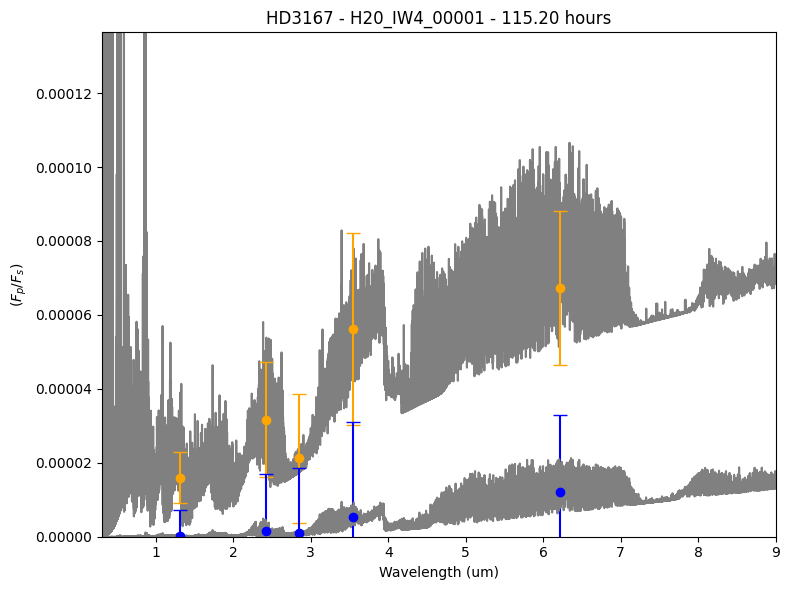

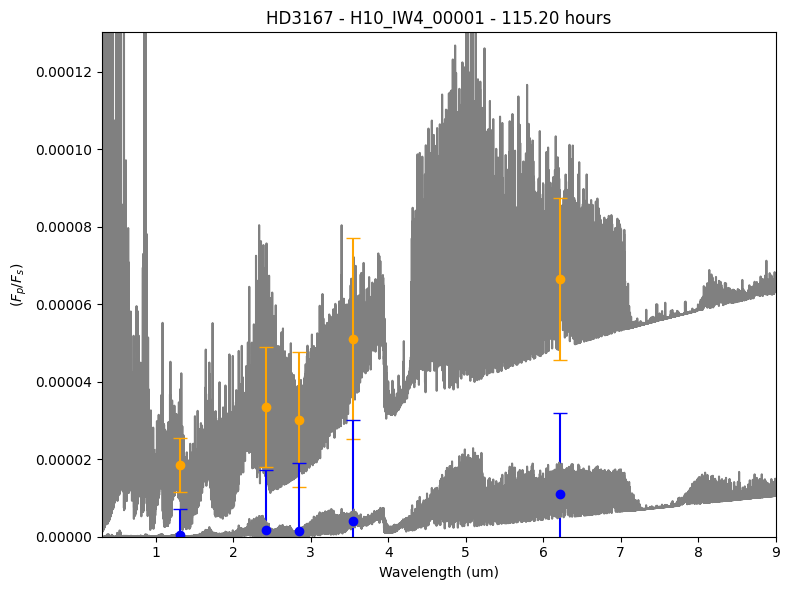

In [36]:
name = 'HD3167'
transits = 5
plot = True

for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

    # open TP profile with TauREx
    temp_profile = TemperatureFile(planetdir, skiprows=1, 
                               temp_col=2, press_col=0, 
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    #read-in the atmospheric composition
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)
    planet_all[name][sim_name] = {
        'simulation_folder': simulation_folder,
        'temp_profile': temp_profile,
        'temp_profile_terminator': temp_profile_terminator,
        'surface_pressure': pmax,
        'mixing_ratios': {
            'H2O': H2O_x,
            'CO2': CO2_x,
            'CH4': CH4_x,
            'CO': CO_x,
            'NH3': NH3_x,
            'N2': N2_x,
            'SO2': SO2_x,
            'S2': S2_x,
            'O2': O2_x,
            'H2': H2_x,
            'H2S': H2S_x
        }
    }

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    em = EmissionModel(
    planet=planet,
    temperature_profile=temp_profile,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em.add_contribution(AbsorptionContribution())
    em.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em.add_contribution(RayleighContribution())

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em.build()
    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid, fpfs, tau, _ = em.model()
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid = 10000/wngrid[::-1]; wlgrid_t = 10000/wngrid_t[::-1]
    fpfs = fpfs[::-1]; fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

    #instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output = fb.bindown(wlgrid, fpfs)
    output_t = fb.bindown(wlgrid_t, fpfs_t)

    N = transits #number of observed transits

    plt.figure(figsize=(8,6))
    plt.plot(wlgrid, fpfs, color='gray')
    #plt.errorbar(output[0], np.random.normal(output[1],noise/np.sqrt(10)), yerr=noise/np.sqrt(10), fmt='o')
    #plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(N), capsize=5, fmt='o', color='orange', alpha=0.67)

    yerr = noise / np.sqrt(N)

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
        output_t[1] + yerr,
        output_t[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.0001 * (ymax - ymin)
    if ymin - pad < 0:
        plt.ylim(0, ymax + pad)
    else:
        plt.ylim(ymin - pad, ymax + pad)

    time = float(planet_period[planet_names.index(name)]) * N * 24 #in hours

    #bin down to new points for terminator and substellar profiles
    results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, new_point1, new_point2, new_point3, 
                           new_point4, new_point5, new_point6, new_point7, 
                           new_point8, new_point11,
                           new_point12)

    results = bindown_multiple(output, noise, wlgrid, fpfs, transits, 
                            name, new_point1, new_point2, new_point3, 
                            new_point4, new_point5, new_point6, new_point7, 
                            new_point8, new_point11,
                            new_point12)
            
    new_points = make_next_level_points(results); new_points_t = make_next_level_points(results_t)

    results_level2 = bindown_multiple(output, noise, wlgrid, fpfs, transits, name, *new_points)
    results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, *new_points_t)
    
    # FINAL BINNED POINTS PLOT
    for out in results_level2:
        plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='orange')
    for out in results_level2_t:
        plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='blue')


    plt.xlabel("Wavelength (um)")
    plt.ylabel("$(F_p/F_s)$")
    #plt.xscale("log")
    plt.xlim(0.3, 9)
    plt.title(f"{name} - {os.path.basename(simulation_folder)} - {time:.2f} hours")
    plt.tight_layout()

    plt.plot(wlgrid_t, fpfs_t, color='gray')
    #plt.errorbar(output_t[0], np.random.normal(output_t[1],noise/np.sqrt(N)), yerr=noise/np.sqrt(10), fmt='o')
    #plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N), capsize=5, fmt='o', color='blue', alpha=0.67)

    plt.savefig(f"PLANETS/{name}/{os.path.basename(simulation_folder)}_emission_spectrum_{N}.pdf", format='pdf')
    show()
    close()

## K2141b

## LHS1478b

## TOI431b

## TOI500b

Processing PLANETS/TOI500/H20_IW4_00001...


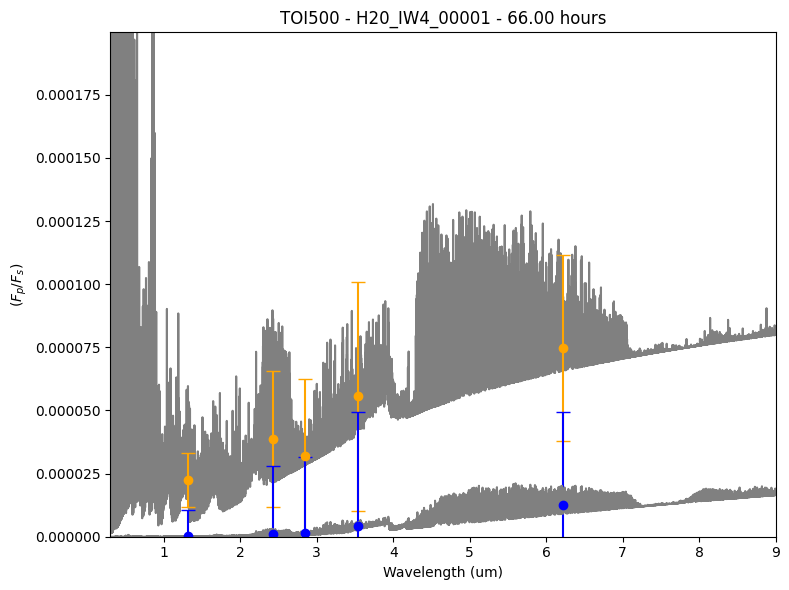

Processing PLANETS/TOI500/H20_IW2_00001...
Mixing ratios renormalized for TOI500 in PLANETS/TOI500/H20_IW2_00001.


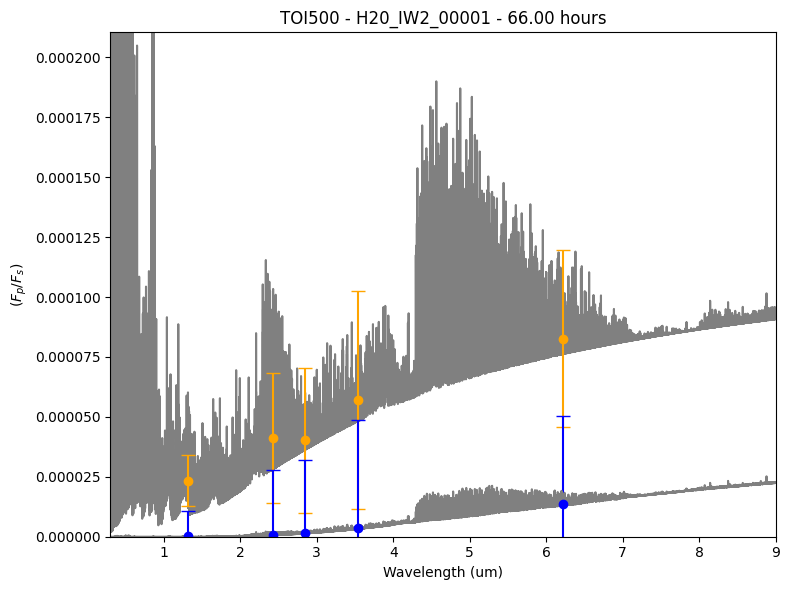

Processing PLANETS/TOI500/H10_IW4_00001...
No atm.nc file found in PLANETS/TOI500/H10_IW4_00001. Skipping.


In [37]:
name = 'TOI500'
transits = 5
plot = True

for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue
    print(f"Processing {simulation_folder}...")

    #check that an atm.nc file exists in the directory, if not then skip
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break
    if atm_file is None:
        print(f"No atm.nc file found in {simulation_folder}. Skipping.")
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

    # open TP profile with TauREx
    temp_profile = TemperatureFile(planetdir, skiprows=1, 
                               temp_col=2, press_col=0, 
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

   #check that the mixing ratios sum to 1 or less
    total_mixing_ratio = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_mixing_ratio > 1:
        print(f"Warning: Total mixing ratio for {name} in {simulation_folder} exceeds 1. Total: {total_mixing_ratio}")
        #renormalize mixing ratios if they sum to more than 1
        H2O_x /= total_mixing_ratio
        CO2_x /= total_mixing_ratio
        CH4_x /= total_mixing_ratio
        CO_x /= total_mixing_ratio
        NH3_x /= total_mixing_ratio
        N2_x /= total_mixing_ratio
        SO2_x /= total_mixing_ratio
        S2_x /= total_mixing_ratio
        O2_x /= total_mixing_ratio
        H2_x /= total_mixing_ratio
        H2S_x /= total_mixing_ratio
        print(f"Mixing ratios renormalized for {name} in {simulation_folder}.")

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)
    planet_all[name][sim_name] = {
        'simulation_folder': simulation_folder,
        'temp_profile': temp_profile,
        'temp_profile_terminator': temp_profile_terminator,
        'surface_pressure': pmax,
        'mixing_ratios': {
            'H2O': H2O_x,
            'CO2': CO2_x,
            'CH4': CH4_x,
            'CO': CO_x,
            'NH3': NH3_x,
            'N2': N2_x,
            'SO2': SO2_x,
            'S2': S2_x,
            'O2': O2_x,
            'H2': H2_x,
            'H2S': H2S_x
        }
    }

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    em = EmissionModel(
    planet=planet,
    temperature_profile=temp_profile,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em.add_contribution(AbsorptionContribution())
    em.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em.add_contribution(RayleighContribution())

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em.build()
    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid, fpfs, tau, _ = em.model()
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid = 10000/wngrid[::-1]; wlgrid_t = 10000/wngrid_t[::-1]
    fpfs = fpfs[::-1]; fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

    #instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output = fb.bindown(wlgrid, fpfs)
    output_t = fb.bindown(wlgrid_t, fpfs_t)

    N = transits #number of observed transits

    plt.figure(figsize=(8,6))
    plt.plot(wlgrid, fpfs, color='gray')
    #plt.errorbar(output[0], np.random.normal(output[1],noise/np.sqrt(10)), yerr=noise/np.sqrt(10), fmt='o')
    #plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(N), capsize=5, fmt='o', color='orange', alpha=0.67)

    yerr = noise / np.sqrt(N)

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
        output_t[1] + yerr,
        output_t[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.0001 * (ymax - ymin)
    if ymin - pad < 0:
        plt.ylim(0, ymax + pad)
    else:
        plt.ylim(ymin - pad, ymax + pad)

    time = float(planet_period[planet_names.index(name)]) * N * 24 #in hours

    #bin down to new points for terminator and substellar profiles
    results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, new_point1, new_point2, new_point3, 
                           new_point4, new_point5, new_point6, new_point7, 
                           new_point8, new_point11,
                           new_point12)

    results = bindown_multiple(output, noise, wlgrid, fpfs, transits, 
                            name, new_point1, new_point2, new_point3, 
                            new_point4, new_point5, new_point6, new_point7, 
                            new_point8, new_point11,
                            new_point12)
            
    new_points = make_next_level_points(results); new_points_t = make_next_level_points(results_t)

    results_level2 = bindown_multiple(output, noise, wlgrid, fpfs, transits, name, *new_points)
    results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, *new_points_t)
    
    # FINAL BINNED POINTS PLOT
    for out in results_level2:
        plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='orange')
    for out in results_level2_t:
        plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='blue')


    plt.xlabel("Wavelength (um)")
    plt.ylabel("$(F_p/F_s)$")
    #plt.xscale("log")
    plt.xlim(0.3, 9)
    plt.title(f"{name} - {os.path.basename(simulation_folder)} - {time:.2f} hours")
    plt.tight_layout()

    plt.plot(wlgrid_t, fpfs_t, color='gray')
    #plt.errorbar(output_t[0], np.random.normal(output_t[1],noise/np.sqrt(N)), yerr=noise/np.sqrt(10), fmt='o')
    #plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N), capsize=5, fmt='o', color='blue', alpha=0.67)

    plt.savefig(f"PLANETS/{name}/{os.path.basename(simulation_folder)}_emission_spectrum_{N}.pdf", format='pdf')
    show()
    close()

## TOI1416b

Processing PLANETS/TOI1416/H20_IW0_00001...


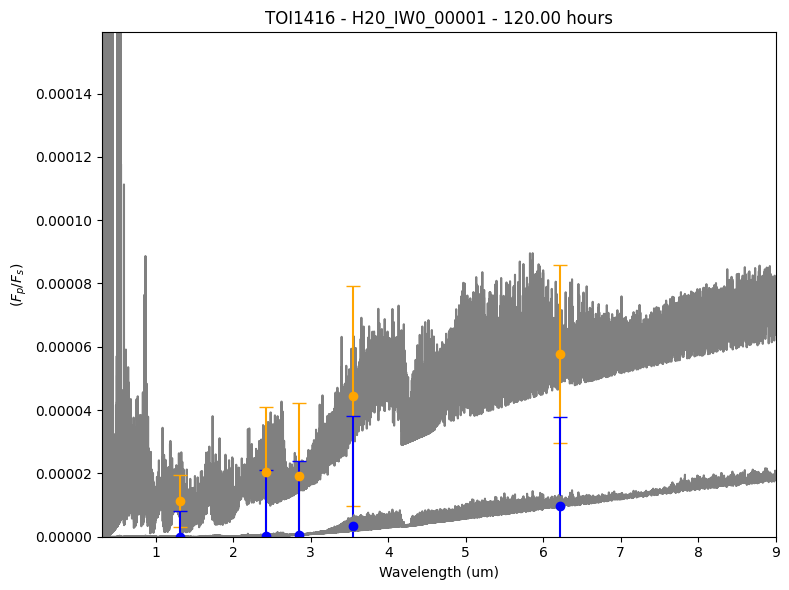

Processing PLANETS/TOI1416/H10_IW0_00001...
No atm.nc file found in PLANETS/TOI1416/H10_IW0_00001. Skipping.
Processing PLANETS/TOI1416/H10_IW4_00001...


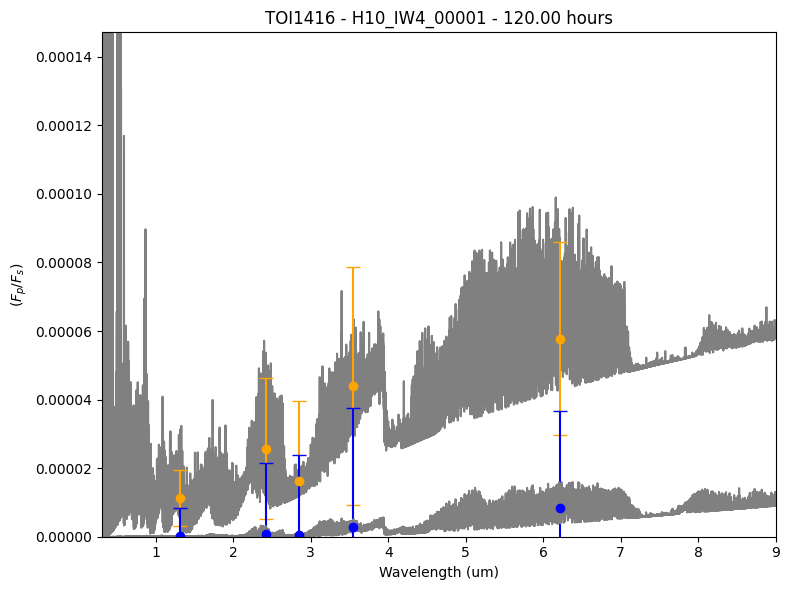

In [38]:
name = 'TOI1416'
transits = 5
plot = True

for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue
    print(f"Processing {simulation_folder}...")

    #check that an atm.nc file exists in the directory, if not then skip
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break
    if atm_file is None:
        print(f"No atm.nc file found in {simulation_folder}. Skipping.")
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

    # open TP profile with TauREx
    temp_profile = TemperatureFile(planetdir, skiprows=1, 
                               temp_col=2, press_col=0, 
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

   #check that the mixing ratios sum to 1 or less
    total_mixing_ratio = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_mixing_ratio > 1:
        print(f"Warning: Total mixing ratio for {name} in {simulation_folder} exceeds 1. Total: {total_mixing_ratio}")
        #renormalize mixing ratios if they sum to more than 1
        H2O_x /= total_mixing_ratio
        CO2_x /= total_mixing_ratio
        CH4_x /= total_mixing_ratio
        CO_x /= total_mixing_ratio
        NH3_x /= total_mixing_ratio
        N2_x /= total_mixing_ratio
        SO2_x /= total_mixing_ratio
        S2_x /= total_mixing_ratio
        O2_x /= total_mixing_ratio
        H2_x /= total_mixing_ratio
        H2S_x /= total_mixing_ratio
        print(f"Mixing ratios renormalized for {name} in {simulation_folder}.")

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)
    planet_all[name][sim_name] = {
        'simulation_folder': simulation_folder,
        'temp_profile': temp_profile,
        'temp_profile_terminator': temp_profile_terminator,
        'surface_pressure': pmax,
        'mixing_ratios': {
            'H2O': H2O_x,
            'CO2': CO2_x,
            'CH4': CH4_x,
            'CO': CO_x,
            'NH3': NH3_x,
            'N2': N2_x,
            'SO2': SO2_x,
            'S2': S2_x,
            'O2': O2_x,
            'H2': H2_x,
            'H2S': H2S_x
        }
    }

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    em = EmissionModel(
    planet=planet,
    temperature_profile=temp_profile,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em.add_contribution(AbsorptionContribution())
    em.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em.add_contribution(RayleighContribution())

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em.build()
    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid, fpfs, tau, _ = em.model()
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid = 10000/wngrid[::-1]; wlgrid_t = 10000/wngrid_t[::-1]
    fpfs = fpfs[::-1]; fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

    #instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output = fb.bindown(wlgrid, fpfs)
    output_t = fb.bindown(wlgrid_t, fpfs_t)

    N = transits #number of observed transits

    plt.figure(figsize=(8,6))
    plt.plot(wlgrid, fpfs, color='gray')
    #plt.errorbar(output[0], np.random.normal(output[1],noise/np.sqrt(10)), yerr=noise/np.sqrt(10), fmt='o')
    #plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(N), capsize=5, fmt='o', color='orange', alpha=0.67)

    yerr = noise / np.sqrt(N)

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
        output_t[1] + yerr,
        output_t[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.0001 * (ymax - ymin)
    if ymin - pad < 0:
        plt.ylim(0, ymax + pad)
    else:
        plt.ylim(ymin - pad, ymax + pad)

    time = float(planet_period[planet_names.index(name)]) * N * 24 #in hours

    #bin down to new points for terminator and substellar profiles
    results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, new_point1, new_point2, new_point3, 
                           new_point4, new_point5, new_point6, new_point7, 
                           new_point8, new_point11,
                           new_point12)

    results = bindown_multiple(output, noise, wlgrid, fpfs, transits, 
                            name, new_point1, new_point2, new_point3, 
                            new_point4, new_point5, new_point6, new_point7, 
                            new_point8, new_point11,
                            new_point12)
            
    new_points = make_next_level_points(results); new_points_t = make_next_level_points(results_t)

    results_level2 = bindown_multiple(output, noise, wlgrid, fpfs, transits, name, *new_points)
    results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, *new_points_t)
    
    # FINAL BINNED POINTS PLOT
    for out in results_level2:
        plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='orange')
    for out in results_level2_t:
        plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='blue')


    plt.xlabel("Wavelength (um)")
    plt.ylabel("$(F_p/F_s)$")
    #plt.xscale("log")
    plt.xlim(0.3, 9)
    plt.title(f"{name} - {os.path.basename(simulation_folder)} - {time:.2f} hours")
    plt.tight_layout()

    plt.plot(wlgrid_t, fpfs_t, color='gray')
    #plt.errorbar(output_t[0], np.random.normal(output_t[1],noise/np.sqrt(N)), yerr=noise/np.sqrt(10), fmt='o')
    #plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N), capsize=5, fmt='o', color='blue', alpha=0.67)

    plt.savefig(f"PLANETS/{name}/{os.path.basename(simulation_folder)}_emission_spectrum_{N}.pdf", format='pdf')
    show()
    close()

## TOI1807b

Processing PLANETS/TOI1807/H20_IW0_00001...


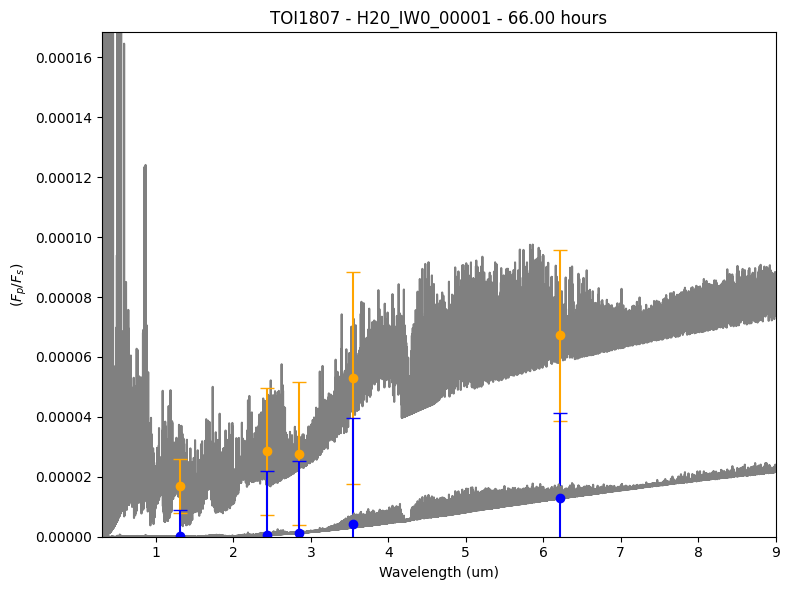

Processing PLANETS/TOI1807/H5_IW4_00001...


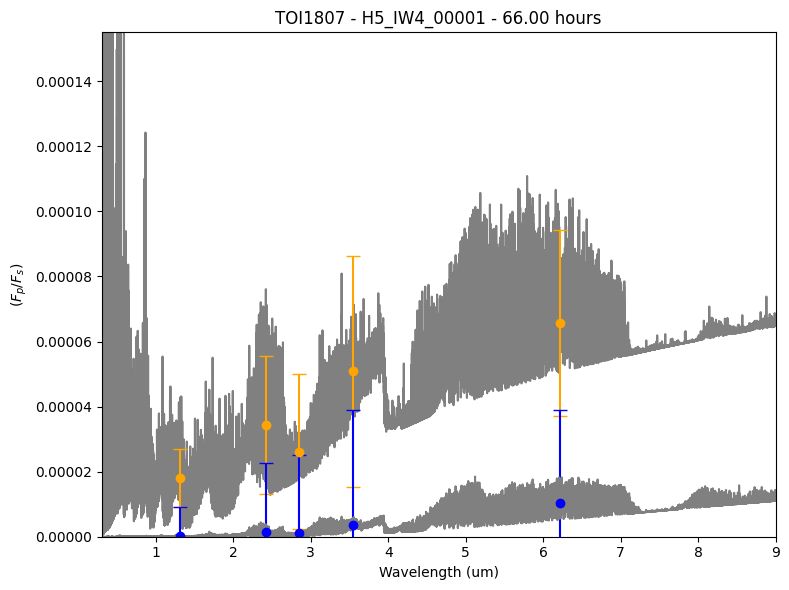

Processing PLANETS/TOI1807/H10_IW0_00001...


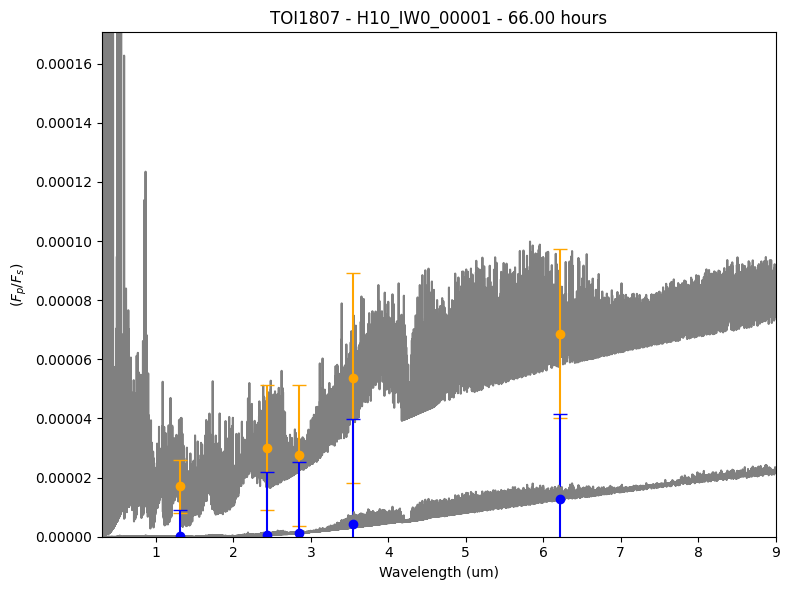

In [39]:
name = 'TOI1807'
transits = 5
plot = True

for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue
    print(f"Processing {simulation_folder}...")

    #check that an atm.nc file exists in the directory, if not then skip
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break
    if atm_file is None:
        print(f"No atm.nc file found in {simulation_folder}. Skipping.")
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"

    # open TP profile with TauREx
    temp_profile = TemperatureFile(planetdir, skiprows=1, 
                               temp_col=2, press_col=0, 
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

   #check that the mixing ratios sum to 1 or less
    total_mixing_ratio = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_mixing_ratio > 1:
        print(f"Warning: Total mixing ratio for {name} in {simulation_folder} exceeds 1. Total: {total_mixing_ratio}")
        #renormalize mixing ratios if they sum to more than 1
        H2O_x /= total_mixing_ratio
        CO2_x /= total_mixing_ratio
        CH4_x /= total_mixing_ratio
        CO_x /= total_mixing_ratio
        NH3_x /= total_mixing_ratio
        N2_x /= total_mixing_ratio
        SO2_x /= total_mixing_ratio
        S2_x /= total_mixing_ratio
        O2_x /= total_mixing_ratio
        H2_x /= total_mixing_ratio
        H2S_x /= total_mixing_ratio
        print(f"Mixing ratios renormalized for {name} in {simulation_folder}.")

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)
    planet_all[name][sim_name] = {
        'simulation_folder': simulation_folder,
        'temp_profile': temp_profile,
        'temp_profile_terminator': temp_profile_terminator,
        'surface_pressure': pmax,
        'mixing_ratios': {
            'H2O': H2O_x,
            'CO2': CO2_x,
            'CH4': CH4_x,
            'CO': CO_x,
            'NH3': NH3_x,
            'N2': N2_x,
            'SO2': SO2_x,
            'S2': S2_x,
            'O2': O2_x,
            'H2': H2_x,
            'H2S': H2S_x
        }
    }

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    em = EmissionModel(
    planet=planet,
    temperature_profile=temp_profile,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em.add_contribution(AbsorptionContribution())
    em.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em.add_contribution(RayleighContribution())

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em.build()
    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid, fpfs, tau, _ = em.model()
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid = 10000/wngrid[::-1]; wlgrid_t = 10000/wngrid_t[::-1]
    fpfs = fpfs[::-1]; fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional

    #instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output = fb.bindown(wlgrid, fpfs)
    output_t = fb.bindown(wlgrid_t, fpfs_t)

    N = transits #number of observed transits

    plt.figure(figsize=(8,6))
    plt.plot(wlgrid, fpfs, color='gray')
    #plt.errorbar(output[0], np.random.normal(output[1],noise/np.sqrt(10)), yerr=noise/np.sqrt(10), fmt='o')
    #plt.errorbar(output[0], output[1], yerr=noise/np.sqrt(N), capsize=5, fmt='o', color='orange', alpha=0.67)

    yerr = noise / np.sqrt(N)

    # set appropriate y-limits based on the singular plot
    y_all = np.concatenate([
        output[1] + yerr,
        output[1] - yerr,
        output_t[1] + yerr,
        output_t[1] - yerr,
    ])

    ymin = y_all.min()
    ymax = y_all.max()

    pad = 0.0001 * (ymax - ymin)
    if ymin - pad < 0:
        plt.ylim(0, ymax + pad)
    else:
        plt.ylim(ymin - pad, ymax + pad)

    time = float(planet_period[planet_names.index(name)]) * N * 24 #in hours

    #bin down to new points for terminator and substellar profiles
    results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, new_point1, new_point2, new_point3, 
                           new_point4, new_point5, new_point6, new_point7, 
                           new_point8, new_point11,
                           new_point12)

    results = bindown_multiple(output, noise, wlgrid, fpfs, transits, 
                            name, new_point1, new_point2, new_point3, 
                            new_point4, new_point5, new_point6, new_point7, 
                            new_point8, new_point11,
                            new_point12)
            
    new_points = make_next_level_points(results); new_points_t = make_next_level_points(results_t)

    results_level2 = bindown_multiple(output, noise, wlgrid, fpfs, transits, name, *new_points)
    results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, transits, name, *new_points_t)
    
    # FINAL BINNED POINTS PLOT
    for out in results_level2:
        plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='orange')
    for out in results_level2_t:
        plt.errorbar(out[2], out[3], yerr=out[4], capsize=5, fmt='o', color='blue')


    plt.xlabel("Wavelength (um)")
    plt.ylabel("$(F_p/F_s)$")
    #plt.xscale("log")
    plt.xlim(0.3, 9)
    plt.title(f"{name} - {os.path.basename(simulation_folder)} - {time:.2f} hours")
    plt.tight_layout()

    plt.plot(wlgrid_t, fpfs_t, color='gray')
    #plt.errorbar(output_t[0], np.random.normal(output_t[1],noise/np.sqrt(N)), yerr=noise/np.sqrt(10), fmt='o')
    #plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N), capsize=5, fmt='o', color='blue', alpha=0.67)

    plt.savefig(f"PLANETS/{name}/{os.path.basename(simulation_folder)}_emission_spectrum_{N}.pdf", format='pdf')
    show()
    close()

In [42]:
#save dictionary with all planets, simulations, temperature profiles, and mixing ratios as a pickle file
with open('planet_all.pkl', 'wb') as f:
    pickle.dump(planet_all, f)

## Plot of all atmospheres

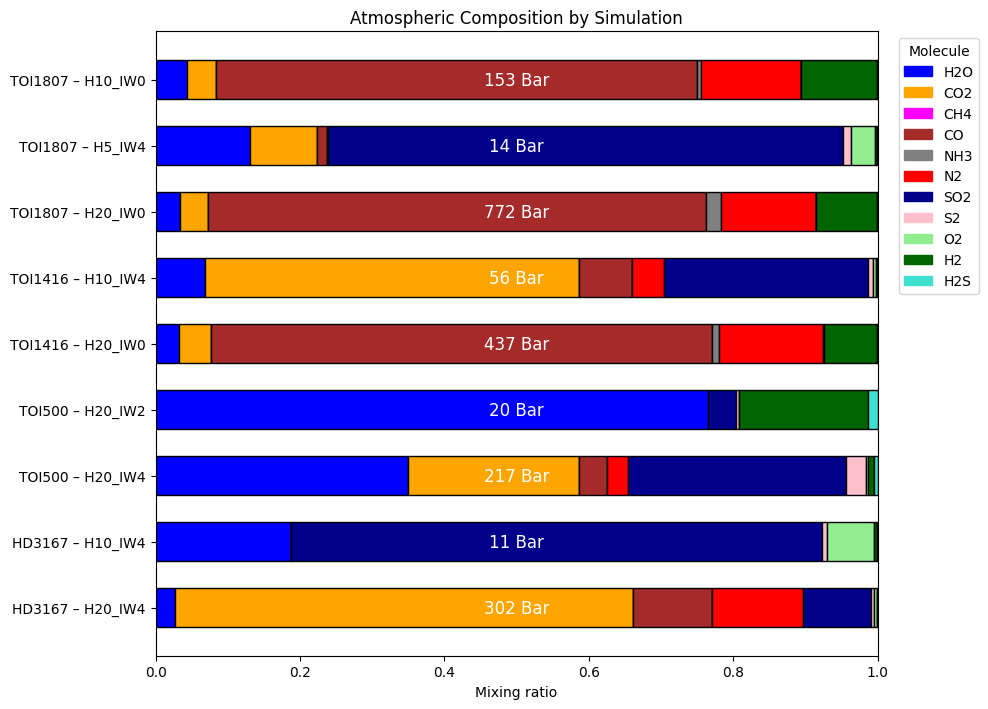

In [46]:
molecules = ['H2O', 'CO2', 'CH4', 'CO', 'NH3', 'N2',
             'SO2', 'S2', 'O2', 'H2', 'H2S']

colors = ['blue', 'orange', 'magenta', 'brown', 'gray',
          'red', 'darkblue', 'pink', 'lightgreen',
          'darkgreen', 'turquoise']

# flatten planet_all into a list of (planet, sim, data)
entries = []
for planet, sims in planet_all.items():
    for sim_name, data in sims.items():
        entries.append((planet, sim_name, data))

n = len(entries)

fig, ax = plt.subplots(figsize=(10, 0.8 * n))

y_pos = np.arange(n)

for i, (planet, sim_name, data) in enumerate(entries):
    left = 0.0

    for mol, col in zip(molecules, colors):
        frac = data['mixing_ratios'].get(mol, 0.0)
        if frac > 0:
            ax.barh(
                i,
                frac,
                left=left,
                color=col,
                edgecolor='black',
                height=0.6,
            )
            left += frac

    # surface pressure label in the center
    p_surf = data['surface_pressure']/1e5 # convert Pa to bar
    ax.text(
        0.5,
        i,
        f"{p_surf:.0f} Bar",
        va='center',
        ha='center',
        fontsize=12,
        color='white',
        transform=ax.get_yaxis_transform()
    )

# y-axis labels: planet name + simulation name
labels = [f"{planet} – {sim[:-6]}" for planet, sim, _ in entries]

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)

ax.set_xlabel("Mixing ratio")
ax.set_xlim(0, 1)
ax.set_title("Atmospheric Composition by Simulation")

# legend
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
ax.legend(
    handles,
    molecules,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Molecule"
)

plt.tight_layout()
plt.show()



In [47]:
print(len(planet_all))

8
